# 3. Question Formulation
## 3.1 Research Question: The Power of "Passive Income"
**The Question**

***“To what extent does the income-prediction model rely on passive income features (Capital Gain/Loss) compared with active income derived from labor? Specifically, if we completely remove investment-related attributes, by how much will the Random Forest model’s ability to detect high-income individuals (Recall for the >50K class) decline?”***

Note: This question is designed to test whether the model can identify high-income individuals purely from labor-related features (occupation, working hours, education) or whether it requires information about accumulated assets.

**Motivation & Benefit**
- **Why is this question worth investigating?**
    * Although capital.gain and capital.loss are highly sparse in the 1994 Census data, wealth is often concentrated in a small fraction of the population, raising the possibility that these seemingly “zero-heavy” features capture critical signals of upper-class status.

- **What benefits or insights might this research provide?**
    * It helps distinguish wealth derived from labor income versus investment income and identifies potential model blindspots that overlook individuals with low wages but high capital returns.

- **Who would care about the answer?**
    * Banks, credit institutions, and policymakers interested in accurate wealth assessment and income inequality analysis.

- **What real-world problem does this inform?**
    * It improves targeting and decision-making in financial services by preventing misclassification of high–net-worth individuals based solely on labor income.

**Methodology**

- **Experimental Design:** We compare two data settings.  
    * (1) Full Data, including capital.gain and capital.loss, and  
    * (2) Labor-Only Data, where asset-related features are removed.

- **Applied Models:**
    - **Logistic Regression**: Serves as an interpretable baseline, allowing direct assessment of the relationship between capital features and high-income probability.
    - **Random Forest**: Handles sparse and skewed capital features effectively, captures non-linear threshold effects, and provides feature importance to validate insights from the linear model.

**Analysis Workflow**  

   - To answer this research question, we follow a four-step comparative workflow:

1. **Data Preparation (Unified Preprocessing):**
   * Perform data cleaning.
   * **Feature Engineering:** Apply ***One-Hot Encoding*** for categorical variables and **mandatory** ***Standard Scaling*** for numerical variables (to ensure optimal Logistic Regression performance and coefficient comparability).
   * Split the dataset into a consistent Train/Test set.

2. **Model Training (Dual-Model Setup):**
   * Train **Logistic Regression** as the baseline model.
   * Train **Random Forest** as the challenger model.

3. **Performance Comparison**
   - Evaluate model performance using **Confusion Matrices** for each model and scenario.  
     This allows a clear view of **True Positives, False Positives, True Negatives, and False Negatives**, with a focus on detecting >50K earners.  
   - **Goal:** Assess how removing Capital Income features impacts the model’s ability to correctly identify high-income individuals.

4. **Interpretability Check**
   - Provide an **overall summary of feature importance** and model behavior:
   - **Analysis:** Compare which features the models rely on most, and evaluate the effect of removing capital-related features on the overall predictive logic.


### 3.1.1 Data Preparation & Scenario Construction

We are setting up a **2x2 Factorial Experiment** comparing two algorithms against two feature scenarios. This requires a unified preprocessing pipeline that generates two distinct feature sets for training:

1.  **Scenario A (Full Data):** Uses all available features, including Capital Gain/Loss.
2.  **Scenario B (Labor-Only Data):** Explicitly excludes `capital.gain` and `capital.loss`, forcing the model to rely only on labor and demographic features.

**Key Preprocessing Steps:**
* **Cleaning:** Handle missing values ('?') and duplicates.
* **Feature Engineering:** Apply **Standard Scaling** (essential for Logistic Regression) and **One-Hot Encoding** to both raw feature sets.
* **Synchronized Split:** Use the same `random_state` for all train/test splits to ensure that rows align perfectly across the models.

#### Step 1 — Cleaning  
In this step, we load the dataset and apply basic cleaning:

* Replace missing values `"?"` with `"Unknown"`.
* Remove duplicate rows.
* Convert the income column into a binary target (1 for >50K, 0 otherwise).
* Prepare two raw feature sets:
  - **Full Features** (includes `capital.gain`, `capital.loss`)
  - **Labor-Only Features** (Capital columns removed)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# 1. Load and Clean Data
df = pd.read_csv("../data/adult.csv")

# Clean missing values and duplicates
df = df.replace("?", "Unknown").drop_duplicates()

# Target variable
y = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

# Columns to ablate for Labor-Only scenario
CAPITAL_COLS = ["capital.gain", "capital.loss"]
TARGET_COL = "income"

print(f"Total rows after cleaning: {df.shape[0]}")
print(f"Target distribution (1 = High Income): {y.mean():.2%}")

# Feature sets
X_raw_full = df.drop(columns=[TARGET_COL])
X_raw_labor = df.drop(columns=[TARGET_COL] + CAPITAL_COLS)


display(df)

Total rows after cleaning: 32537
Target distribution (1 = High Income): 24.09%


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


#### Step 2 — Feature Engineering  
We apply unified preprocessing to both Full and Labor-Only feature sets:

* **Standard Scaling** for all numeric columns  
  (critical for Logistic Regression stability & coefficient comparability).
* **One-Hot Encoding** for categorical variables  
  (`drop_first=True` to avoid multicollinearity).

The same preprocessing function is used for both scenarios to ensure fairness.


In [3]:
def preprocess_and_split(X_raw_data, target_y):
    
    # Split data into train and test first
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw_data, target_y,
        test_size=0.2,
        random_state=42,
        stratify=target_y
    )

    train_data = X_train.copy()
    train_data['target'] = y_train
    test_data = X_test.copy()
    test_data['target'] = y_test
    
    # 3Save raw train/test data to 2 files
    train_data.to_csv(f"../data/train.csv", index=False)
    test_data.to_csv(f"../data/test.csv", index=False)
    
    # Find numeric columns
    numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
    
    # Scale numeric columns (fit on train, apply on train and test)
    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
    
    # One-hot encode categorical columns (drop first to avoid dummy trap)
    X_train_final = pd.get_dummies(X_train_scaled, drop_first=True)
    X_test_final = pd.get_dummies(X_test_scaled, drop_first=True)
    
    # Make sure test has same columns as train
    X_test_final = X_test_final.reindex(columns=X_train_final.columns, fill_value=0)
    
    # Return train/test sets and column names
    return X_train_final, X_test_final, y_train, y_test, X_train_final.columns

#### Step 3 — Synchronized Train/Test Split  
We now apply preprocessing to both datasets:

* **Scenario A — Full Features**
* **Scenario B — Labor-Only Features**

Using the same `random_state=42` ensures that:

- Train/Test splits align perfectly  
- Both models (LogReg & RF) are compared on **identical samples**  
- Ablation is fair and controlled


In [4]:
# Execute preprocessing for both scenarios
X_train_labor, X_test_labor, _, _, _ = preprocess_and_split(X_raw_labor, y)
X_train_full, X_test_full, y_train, y_test, _ = preprocess_and_split(X_raw_full, y)


print("X Training Set:")
display(X_train_full)

print("-" * 40)
print("Data Preparation Complete!")
print(f"Full Feature Count : {X_train_full.shape[1]}")
print(f"Labor Feature Count: {X_train_labor.shape[1]}")
print(f"Training Set Full shape : {X_train_full.shape}")
print(f"Training Set Labor shape: {X_train_labor.shape}")
print("-" * 40)

X Training Set:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Unknown,native.country_Vietnam,native.country_Yugoslavia
25267,-1.285119,-0.470627,-0.031109,-0.146741,-0.217980,-1.663470,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3349,0.183261,2.306554,0.357626,0.440673,-0.217980,1.592035,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
4584,-1.064862,0.492384,-0.419844,-0.146741,-0.217980,-0.035717,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
7003,1.504803,-0.856828,-0.419844,-0.146741,-0.217980,-1.826245,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
882,-0.257253,0.737201,-0.419844,-0.146741,4.422739,0.778159,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31107,-1.578794,0.024156,-1.974785,-0.146741,-0.217980,0.371221,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
10982,0.256680,2.419454,-1.974785,-0.146741,-0.217980,-0.035717,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
22425,1.211127,1.438683,-0.031109,-0.146741,-0.217980,-0.035717,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
8200,-1.211700,0.450316,-0.419844,-0.146741,-0.217980,-0.035717,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False


----------------------------------------
Data Preparation Complete!
Full Feature Count : 99
Labor Feature Count: 97
Training Set Full shape : (26029, 99)
Training Set Labor shape: (26029, 97)
----------------------------------------


### 3.1.2 Model Training
We train four models:

1. **Logistic Regression — Full Features**
2. **Logistic Regression — Labor-Only**
3. **Random Forest — Full Features**
4. **Random Forest — Labor-Only**

This allows us to measure the importance of investment-related features (capital.gain, capital.loss).

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Initialize models
LR_full = LogisticRegression()
LR_labor = LogisticRegression()

RF_full = RandomForestClassifier(random_state=42)
RF_labor = RandomForestClassifier(random_state=42)

# Train models with progress prints
print("Training Logistic Regression (Full Features)...")
LR_full.fit(X_train_full, y_train)
print("Logistic Regression (Full) trained!\n")

print("Training Logistic Regression (Labor-Only Features)...")
LR_labor.fit(X_train_labor, y_train)
print("Logistic Regression (Labor-Only) trained!\n")

print("Training Random Forest (Full Features)...")
RF_full.fit(X_train_full, y_train)
print("Random Forest (Full) trained!\n")

print("Training Random Forest (Labor-Only Features)...")
RF_labor.fit(X_train_labor, y_train)
print("Random Forest (Labor-Only) trained!\n")

print("All 4 models trained successfully!")


Training Logistic Regression (Full Features)...
Logistic Regression (Full) trained!

Training Logistic Regression (Labor-Only Features)...
Logistic Regression (Labor-Only) trained!

Training Random Forest (Full Features)...
Random Forest (Full) trained!

Training Random Forest (Labor-Only Features)...
Random Forest (Labor-Only) trained!

All 4 models trained successfully!


### 3.1.3 Performance Evaluation

We now evaluate all four models using the following metrics:

* Accuracy
* Precision
* Recall (The MOST important metric for detecting >50K earners)
* F1-score

This allows us to quantify how much removing Capital Income features affects model performance.


**Logical Regression Model**


=== LR_Full ===


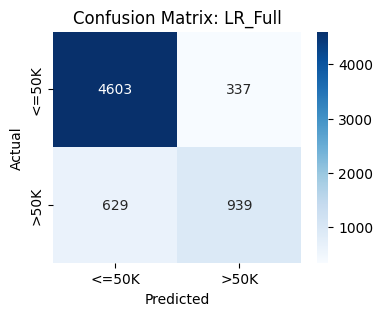

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4940
        >50K       0.74      0.60      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.77      0.78      6508
weighted avg       0.85      0.85      0.85      6508


=== LR_Labor ===


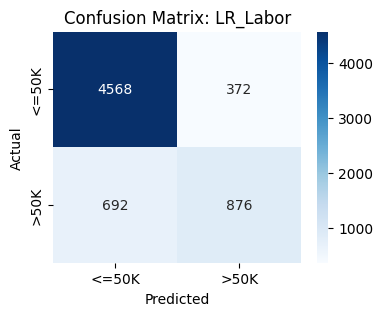

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.92      0.90      4940
        >50K       0.70      0.56      0.62      1568

    accuracy                           0.84      6508
   macro avg       0.79      0.74      0.76      6508
weighted avg       0.83      0.84      0.83      6508



In [6]:
# Models and corresponding test sets
models = {
    "LR_Full": (LR_full, X_test_full),
    "LR_Labor": (LR_labor, X_test_labor),
}

for name, (model, X_test) in models.items():
    print(f"\n=== {name} ===")
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    
    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))


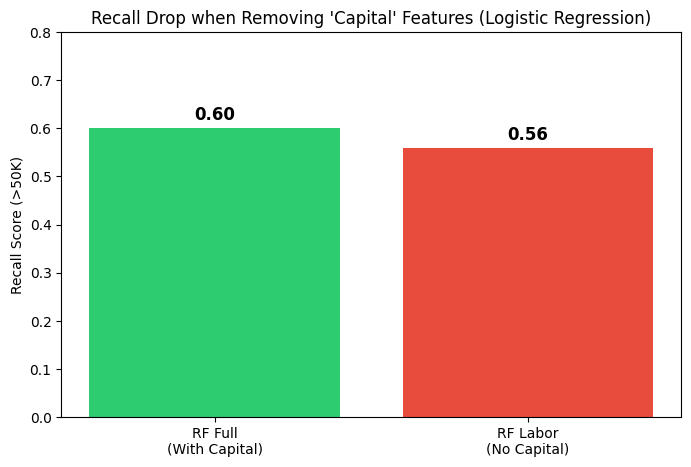

In [7]:
# Define the results manually
model_names = ['RF Full\n(With Capital)', 'RF Labor\n(No Capital)']
recall_scores = [0.60, 0.56] 

# Create a simple bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, recall_scores, color=['#2ecc71', '#e74c3c'])

# Add numbers on top of bars
plt.bar_label(bars, fmt='%.2f', fontsize=12, padding=3, fontweight='bold')

# Final styling
plt.title("Recall Drop when Removing 'Capital' Features (Logistic Regression)", fontsize=12)
plt.ylabel("Recall Score (>50K)")
plt.ylim(0, 0.8)
plt.show()

### **Analysis: Logistic Regression & The Impact of Passive Income**

**1. Quantitative Results:**
* When removing `capital.gain` and `capital.loss`, **Recall (>50K)** dropped from **0.60 to 0.56**.
* **Magnitude of Decline:** Approximately **6.67%**.

**2. Explanation:**
* **Not completely "blind":** The model effectively detects high-income earners based on labor factors (age, occupation, education).
* **The Blindspot:** The 6.7% drop specifically represents the **"hidden wealthy"** (individuals earning primarily through investments) whom the model fails to detect without asset data.

**3. Conclusion:**  
- Logistic Regression partially relies on asset features. While the performance drop is moderate, to optimize the detection of high-value clients, **Capital Gain/Loss should not be skipped**.

**Random Forest Model**


=== RF_Full ===


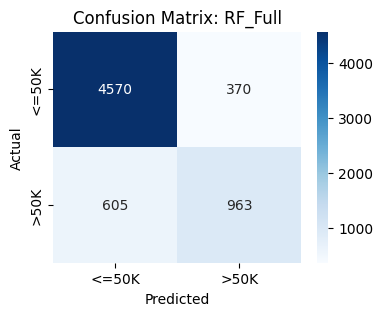

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4940
        >50K       0.72      0.61      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.85      6508


=== RF_Labor ===


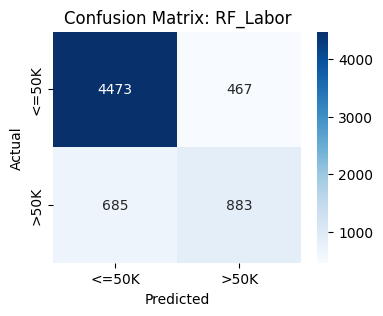

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.91      0.89      4940
        >50K       0.65      0.56      0.61      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.73      0.75      6508
weighted avg       0.82      0.82      0.82      6508



In [8]:
# Models and corresponding test sets
models = {
    "RF_Full": (RF_full, X_test_full),
    "RF_Labor": (RF_labor, X_test_labor)
}

for name, (model, X_test) in models.items():
    print(f"\n=== {name} ===")
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    
    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))


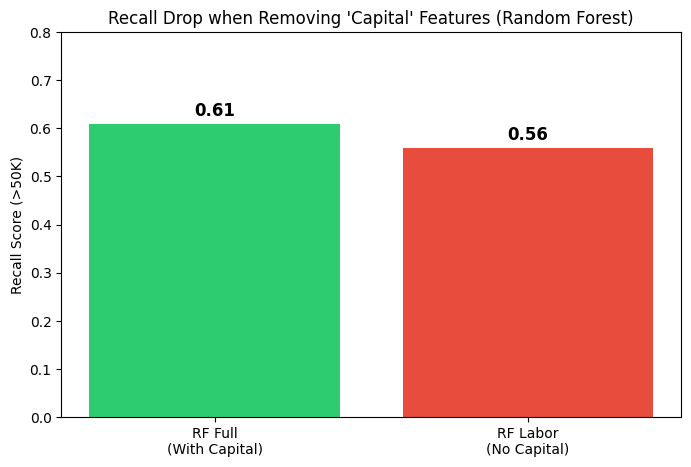

In [9]:
# Define the results manually
model_names = ['RF Full\n(With Capital)', 'RF Labor\n(No Capital)']
recall_scores = [0.61, 0.56] 

# Create a simple bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, recall_scores, color=['#2ecc71', '#e74c3c'])

# Add numbers on top of bars
plt.bar_label(bars, fmt='%.2f', fontsize=12, padding=3, fontweight='bold')

# Final styling
plt.title("Recall Drop when Removing 'Capital' Features (Random Forest)", fontsize=12)
plt.ylabel("Recall Score (>50K)")
plt.ylim(0, 0.8)
plt.show()

### **Analysis: Random Forest & The Impact of Passive Income**

**1. Quantitative Results:**
* **Recall (>50K)** fell from **0.61 to 0.56** when capital features were removed.
* **Magnitude of Decline:** Approximately **8.20%** (steeper than the 6.7% drop seen in Logistic Regression).

**2. Explanation:**
* **Stronger Dependency:** Random Forest excels at capturing non-linear thresholds (e.g., *Capital Gain > 0* implies wealth). Losing this signal hurts RF more than the linear model.
* **The Consequence:** The model becomes significantly "blinded" to the **"hidden wealthy"**—those with low labor income but high investment returns.

**3. Conclusion:**  
- ***Random Forest*** is more slightly sensitive to passive income data in comparison to ***Logistic Regression***. To maximize the detection of high-net-worth individuals, **including Capital features is non-negotiable**.

### 3.1.4 Interpretability Check: Aggregated Feature Importance

**The Problem:**
When using One-Hot Encoding, categorical variables (like `occupation`) are split into many binary features (e.g., `occupation_Sales`, `occupation_Tech`). This dilutes their importance score, making continuous variables like `capital.gain` appear artificially stronger in comparison.

**The Solution:**
To make a fair "Apples-to-Apples" comparison, we must **aggregate (sum)** the importance scores of all dummy variables back to their original parent feature.

* **Random Forest:** We calculate the **Sum of Gini Importance**.
* **Logistic Regression:** We calculate the **Sum of Absolute Coefficients** (magnitude of impact).

**Step 1: Definitions & Helper Functions**

First, we define which features belong to which categorical group and create a helper function to map the One-Hot encoded names back to their original parent features.

In [10]:
# Define original categorical groups in the dataset
categorical_groups = [
    'workclass', 'education', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country'
]

# Helper function to map One-Hot encoded names back to Original names
def map_to_original_feature(encoded_name, groups):
    for group in groups:
        # Check if the feature starts with "group_name_"
        if encoded_name.startswith(group + '_'):
            return group
    return encoded_name # Return as is if it's not a categorical dummy (e.g., age)

**Step 2: Aggregation Calculation**

Here we apply the mapping function to grouped features and sum up their contributions.
* For **Random Forest**, we sum the `feature_importances_`.
* For **Logistic Regression**, we take the absolute value of coefficients (`np.abs`) before summing, as we care about the *magnitude* of influence, not the direction (positive/negative).

In [11]:
# --- A. Process Random Forest (Gini Importance) ---
rf_df = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Importance': RF_full.feature_importances_
})
# Map to original group
rf_df['Original_Feature'] = rf_df['Feature'].apply(lambda x: map_to_original_feature(x, categorical_groups))
# Sum up importance by group
rf_agg = rf_df.groupby('Original_Feature')['Importance'].sum().sort_values(ascending=False)

# --- B. Process Logistic Regression (Absolute Coefficients) ---
lr_df = pd.DataFrame({
    'Feature': X_train_full.columns,
    'Abs_Coefficient': np.abs(LR_full.coef_[0])
})
# Map to original group
lr_df['Original_Feature'] = lr_df['Feature'].apply(lambda x: map_to_original_feature(x, categorical_groups))
# Sum up absolute coefficients by group
lr_agg = lr_df.groupby('Original_Feature')['Abs_Coefficient'].sum().sort_values(ascending=False)

**Step 3: Comparative Visualization**

We visualize the aggregated importance scores side-by-side.
* **Highlighting:** Bars related to `capital` (gain/loss) are highlighted in **RED** to explicitly answer our research question about the role of passive income.

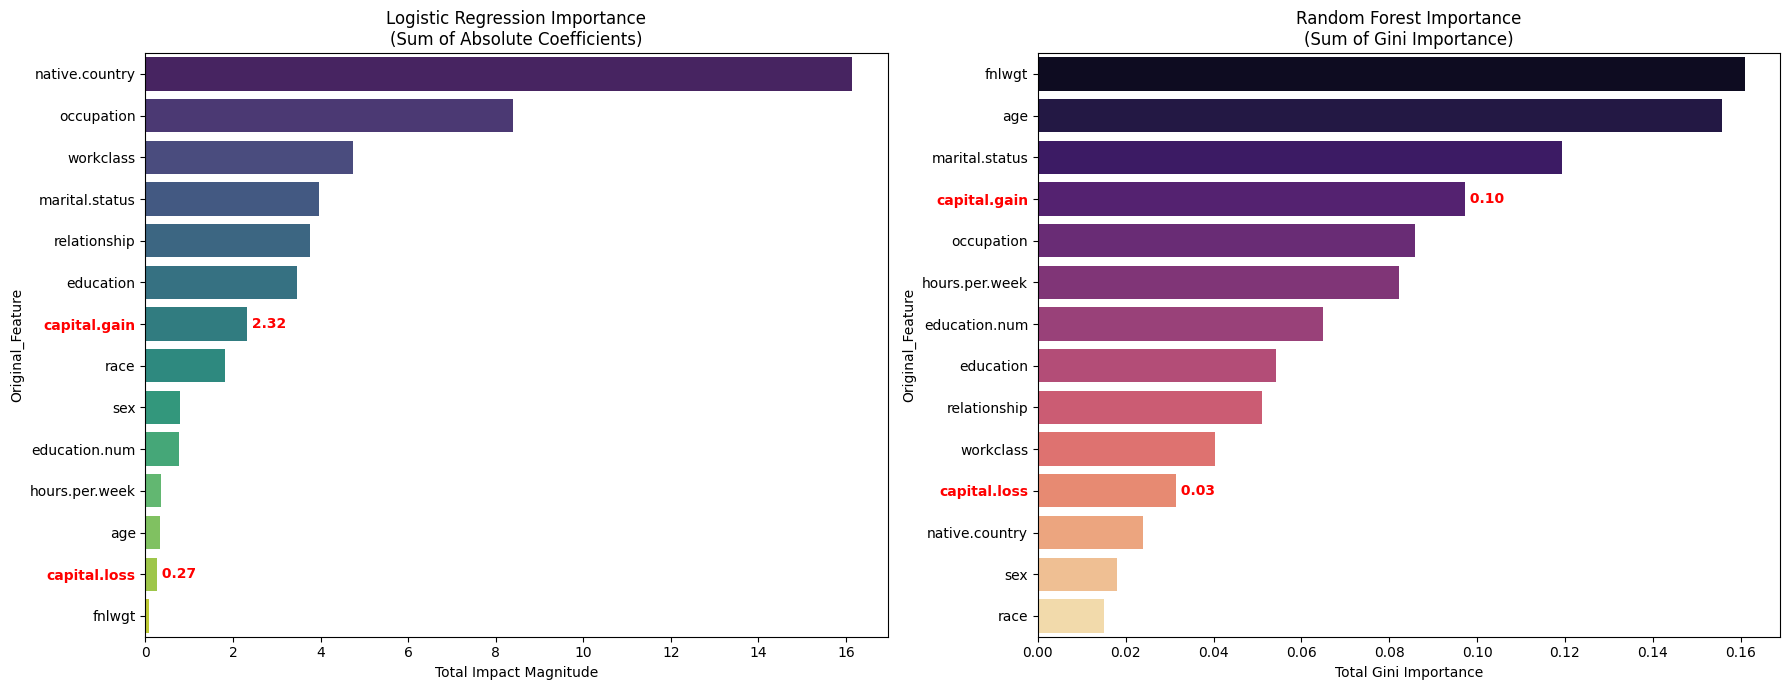

In [12]:
# --- Visualization Setup ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Logistic Regression
sns.barplot(x=lr_agg.values, y=lr_agg.index, ax=axes[0], palette='viridis', hue=lr_agg.index, legend=False)
axes[0].set_title("Logistic Regression Importance\n(Sum of Absolute Coefficients)")
axes[0].set_xlabel("Total Impact Magnitude")

# Plot 2: Random Forest
sns.barplot(x=rf_agg.values, y=rf_agg.index, ax=axes[1], palette='magma', hue=lr_agg.index, legend=False)
axes[1].set_title("Random Forest Importance\n(Sum of Gini Importance)")
axes[1].set_xlabel("Total Gini Importance")

# --- Highlight Capital Features ---
for ax in axes:
    for i, label in enumerate(ax.get_yticklabels()):
        text = label.get_text()
        if 'capital' in text:
            # Change color and weight for Capital features
            label.set_color('red')
            label.set_fontweight('bold')
            
            # Annotate specific value
            val = lr_agg[text] if ax == axes[0] else rf_agg[text]
            ax.text(val, i, f' {val:.2f}', va='center', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

**Chart Analysis**

**1. Logistic Regression (Left Chart):**
* **`capital.gain`** is only ranked **7th**, much lower than factors like Country (`native.country`) or Job (`occupation`).
* **Meaning:** This model does not depend too much on assets. It mainly looks at background and job to predict income. Therefore, when the asset column is removed, it is **less affected** (only a 6.7% drop).

**2. Random Forest (Right Chart):**
* Look at the red bar **`capital.gain`**. It is ranked **Top 4** among the most important factors.
* **Meaning:** The model treats "passive income" as a very strong signal for finding wealthy people. Because it relies so much on this, removing this column causes the prediction ability to **drop sharper** (8.2%).

> **Conclusion:** This chart is **"solid proof"** explaining why Random Forest is more sensitive and "blindsided" more severely than Logistic Regression when asset information is missing.

## **3.2 Research Question: The True Success Probability?**

**The Question**
* **"Does the raw survey data accurately reflect the likelihood of being wealthy for specific demographic groups? Specifically, if we correct for sampling bias using population weights (`fnlwgt`), do minority groups turn out to be richer or poorer than the raw sample suggests?"**

**Motivation & Benefits**

- ***Why is this question worth investigating?***
    * Raw survey proportions can be misleading because demographic groups are unevenly represented in the population. Without correcting for sampling weights, observed income differences may reflect population size rather than true wealth probability.

- ***What benefits or insights might this research provide?***
    * It reveals the true, population-level likelihood of earning high income within each demographic group and identifies groups that are under- or over-sampled among high earners.

- ***Who would care about the answer?***
    * Policymakers, economists, and social science researchers who rely on survey data to study income inequality and demographic disparities.

- ***What real-world problem does this inform?***
    * It supports fair and evidence-based conclusions about wealth distribution, helping avoid biased interpretations that can misguide policy and social analysis.

**Methodology**
We employ a **Within-Group Comparison** strategy:
1.  **Raw Success Rate (Sample View):** $$\frac{\text{Count of Rich in Group}}{\text{Total Count in Group}}$$
2.  **Weighted Success Rate (Population View):** $$\frac{\sum (\text{Weights of Rich in Group})}{\sum (\text{Total Weights in Group})}$$
3.  **Delta Analysis:** The difference between Weighted and Raw rates reveals the sampling bias.

**Analysis Workflow: True Success Probability**

To determine if the raw data accurately reflects the economic reality of each demographic group, we follow this comparative workflow:

1.  **Data Preparation:** * Convert target variable to binary (0/1).
    * **Crucial Step:** Establish the correct denominators for **each specific demographic group**:
        * `Total Sample Count`: Total number of rows belonging to that group (e.g., all Black Males).
        * `Total Population Weight`: Total sum of weights (`fnlwgt`) for that entire group.

2.  **Rate Calculation:** Implement a logic to compute the success probability **within** each `Race` + `Sex` group:
    * **Raw Success Rate:** $\frac{\text{Count of Rich in Group}}{\text{Total Sample Count of Group}}$

    * **Weighted Success Rate:** $\frac{\sum (\text{fnlwgt of Rich in Group})}{\sum (\text{Total fnlwgt of Group})}$

3.  **Visualization:** Use a **Grouped Bar Chart** to visually compare the Raw Rate vs. Weighted Rate side-by-side for each demographic.

4.  **Bias Detection:** Calculate `Delta` to identify if the raw data **Under-estimates** (Positive Delta) or **Over-estimates** (Negative Delta) the wealth probability of specific groups compared to reality.

### 3.2.1 Data Preparation: Optimized Loading & Cleaning

To ensure computational efficiency and statistical accuracy for the weighted analysis, we apply a focused data preparation pipeline:

* **Memory Optimization:** We load only the four essential columns required for this specific research question: `race`, `sex`, `income`, and `fnlwgt`.
* **Handling Missing Values:** Missing data in the Census dataset is encoded as `'?'`. We standardize these to `NaN` and quantify the data loss before removal to ensure sample integrity.
* **Transformation:** The `income` variable is converted into a binary numeric format (`0` and `1`) to facilitate weighted aggregation in subsequent steps.

In [13]:
# Load Data (Optimized: Only load necessary columns)
cols_needed = ['race', 'sex', 'fnlwgt', 'income']
df = pd.read_csv("../data/adult.csv", usecols=cols_needed)

print("Needed data:")
display(df)

# Cleaning Missing Values
# Replace '?' with NaN and drop rows with missing info in these specific columns
df.replace(' ?', np.nan, inplace=True)
df.replace('?', np.nan, inplace=True)

initial_rows = len(df)
print("The number of missing values: ", len(df) - initial_rows)

Needed data:


,fnlwgt,race,sex,income
0,77053,White,Female,<=50K
1,132870,White,Female,<=50K
2,186061,Black,Female,<=50K
3,140359,White,Female,<=50K
4,264663,White,Female,<=50K
...,...,...,...,...
32556,310152,White,Male,<=50K
32557,257302,White,Female,<=50K
32558,154374,White,Male,>50K
32559,151910,White,Female,<=50K


The number of missing values:  0


In [14]:
# Binary Transformation
# Convert income string to integer: '>50K' -> 1, '<=50K' -> 0
df['income_binary'] = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Preview
print("Data ready for weighted analysis.")
display(df)

Data ready for weighted analysis.


,fnlwgt,race,sex,income,income_binary
0,77053,White,Female,<=50K,0
1,132870,White,Female,<=50K,0
2,186061,Black,Female,<=50K,0
3,140359,White,Female,<=50K,0
4,264663,White,Female,<=50K,0
...,...,...,...,...,...
32556,310152,White,Male,<=50K,0
32557,257302,White,Female,<=50K,0
32558,154374,White,Male,>50K,1
32559,151910,White,Female,<=50K,0


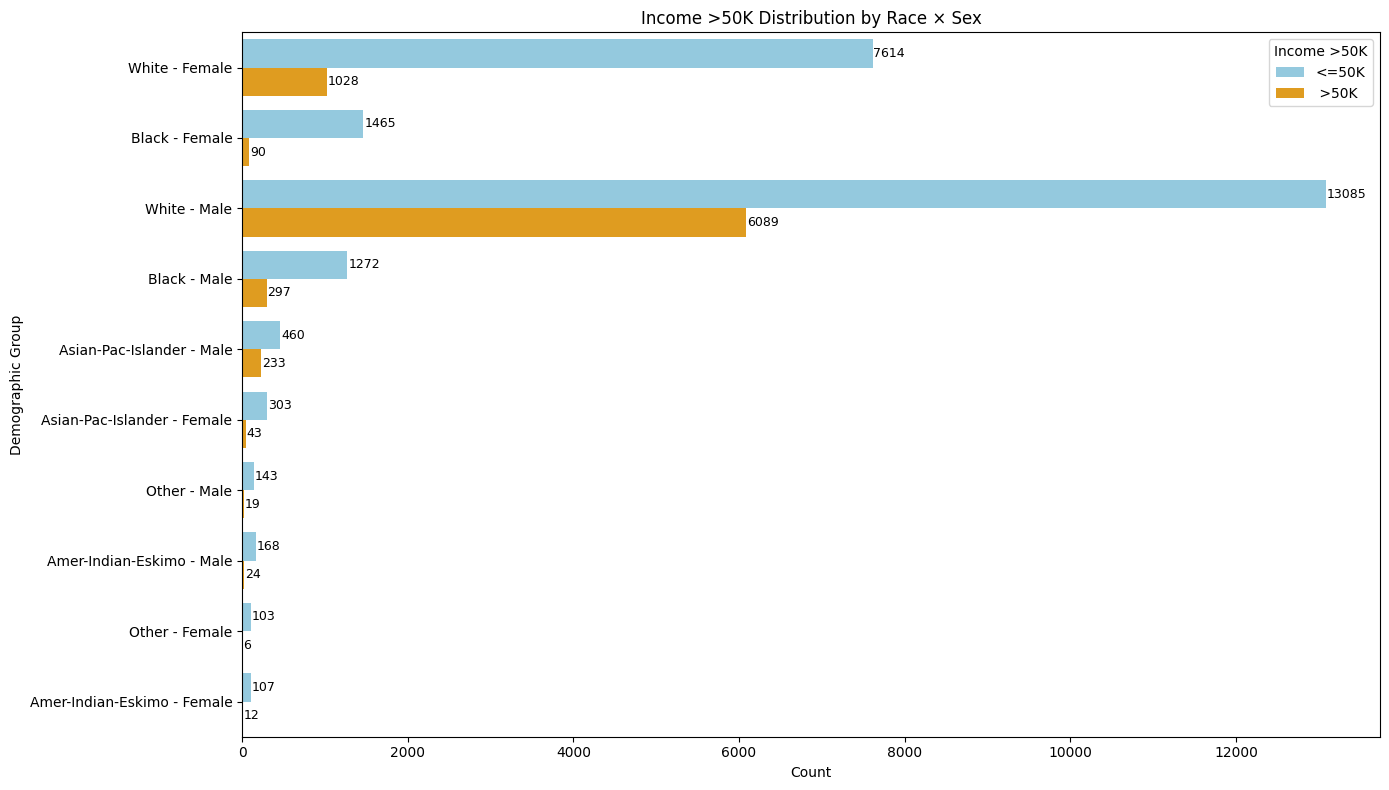

In [15]:
plt.figure(figsize=(14,8))
ax = sns.countplot(
    y=df['race'] + " - " + df['sex'],
    hue=df['income_binary'],
    palette=['skyblue','orange']
)
plt.xlabel("Count")
plt.ylabel("Demographic Group")
plt.title("Income >50K Distribution by Race × Sex")
plt.legend(title="Income >50K", labels=["<=50K"," >50K"])

# Thêm số lượng trên cột
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 10, p.get_y() + p.get_height()/2, int(width), va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 3.2.2 Defining the Global Share Logic

To measure how much each Race–Sex group contributes to the wealthy population (>50K), 
we define the `calculate_global_share` function.

**Global Totals**
- **Total Rich Sample:** number of rows with income_binary = 1  
- **Total Rich Weight:** total fnlwgt among those with income_binary = 1  

**Metrics**
- **Raw Global Share:** Count_of_Rich_in_Group / Total_Rich_Sample  
- **Weighted Global Share:** Sum(fnlwgt_of_Rich_in_Group) / Total_Rich_Weight  
- **Delta = Weighted – Raw**

**Interpretation**
- **Delta > 0:** Group is under-represented in sample (actual share is higher)  
- **Delta < 0:** Group is over-represented in sample  

In [16]:
# Filter rich individuals
rich_df = df[df['income_binary'] == 1]

# Global denominators
total_sample_count = len(rich_df)
total_pop_weight = rich_df['fnlwgt'].sum()

def calculate_global_share(group):
    rich_group = group[group['income_binary'] == 1]
    
    raw_share = len(rich_group) / total_sample_count
    weighted_share = rich_group['fnlwgt'].sum() / total_pop_weight

    return pd.Series({
        'Rich_Count': len(rich_group),
        'Raw_Global_Share (%)': round(raw_share * 100, 2),
        'Weighted_Global_Share (%)': round(weighted_share * 100, 2),
        'Delta': round((weighted_share - raw_share) * 100, 2),
    })


### 3.2.3 Execution: Calculating Composition Within Each Group

We calculate the wealth composition **within each Race–Sex group** rather than globally.

**Steps**
1. **Grouping:** Group the dataset by `['race', 'sex']`.
2. **Calculation:** For each group, compute:
   - **Raw Share:** proportion of rich individuals in that group  
   - **Weighted Share:** weighted proportion using `fnlwgt`
3. **Delta:** Weighted – Raw, indicating internal group bias.


In [17]:
# Define function for within-group share
def calculate_group_share(group):
    group_total_count = len(group)
    group_total_weight = group['fnlwgt'].sum()
    
    rich_count = group['income_binary'].sum()
    weighted_rich = group.loc[group['income_binary']==1, 'fnlwgt'].sum()
    
    raw_share = rich_count / group_total_count
    weighted_share = weighted_rich / group_total_weight
    
    return pd.Series({
        'Group_Total': group_total_count,
        'Rich_Count': rich_count,
        'Raw_Share (%)': round(raw_share*100,2),
        'Weighted_Share (%)': round(weighted_share*100,2),
        'Delta (%)': round((weighted_share - raw_share)*100,2)
    })

# Apply per Race × Sex group
group_share_df = (
    df.groupby(['race', 'sex'])[['income_binary', 'fnlwgt']]
      .apply(calculate_group_share)
      .reset_index()
)

# Sort by Weighted_Share
group_share_df = group_share_df.sort_values(by='Weighted_Share (%)', ascending=False)

# Display results
display(group_share_df)


,race,sex,Group_Total,Rich_Count,Raw_Share (%),Weighted_Share (%),Delta (%)
3,Asian-Pac-Islander,Male,693.0,233.0,33.62,34.54,0.92
9,White,Male,19174.0,6089.0,31.76,31.41,-0.35
5,Black,Male,1569.0,297.0,18.93,19.12,0.19
0,Amer-Indian-Eskimo,Female,119.0,12.0,10.08,13.21,3.13
1,Amer-Indian-Eskimo,Male,192.0,24.0,12.50,12.00,-0.50
2,Asian-Pac-Islander,Female,346.0,43.0,12.43,12.00,-0.42
8,White,Female,8642.0,1028.0,11.90,11.93,0.03
7,Other,Male,162.0,19.0,11.73,11.23,-0.50
4,Black,Female,1555.0,90.0,5.79,5.59,-0.19
6,Other,Female,109.0,6.0,5.50,5.11,-0.39


### 3.2.3 Comparative Visualization

To detect **Sampling Bias**, we compare **Raw Share** vs **Weighted Share**:

1. **Grouped Bar Chart:** Side-by-side comparison of each group's contribution to the wealthy class.
2. **Diverging Bar Chart:** Shows `Delta = Weighted - Raw` to highlight over- or under-represented groups.

**Goal:** Identify groups whose actual contribution (Weighted) is larger than the sample suggests (Raw).


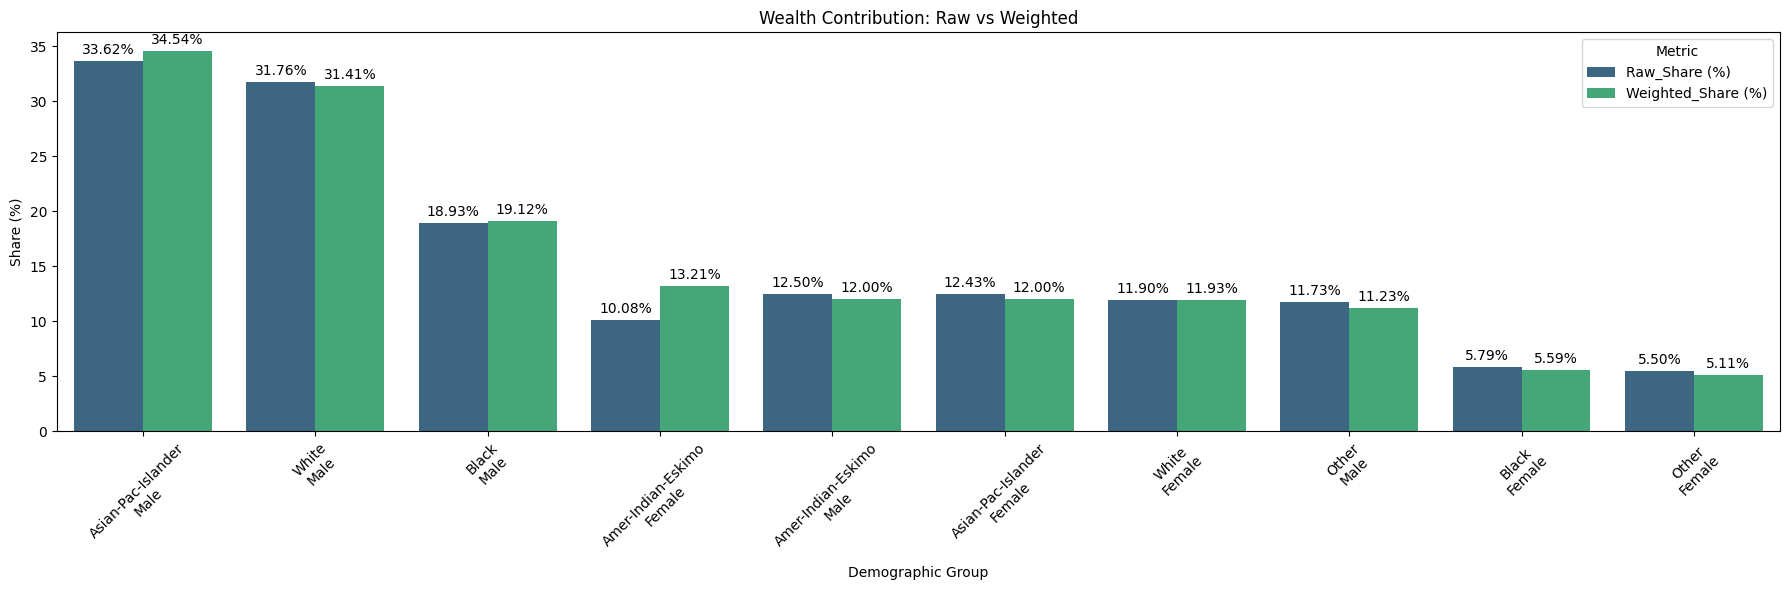

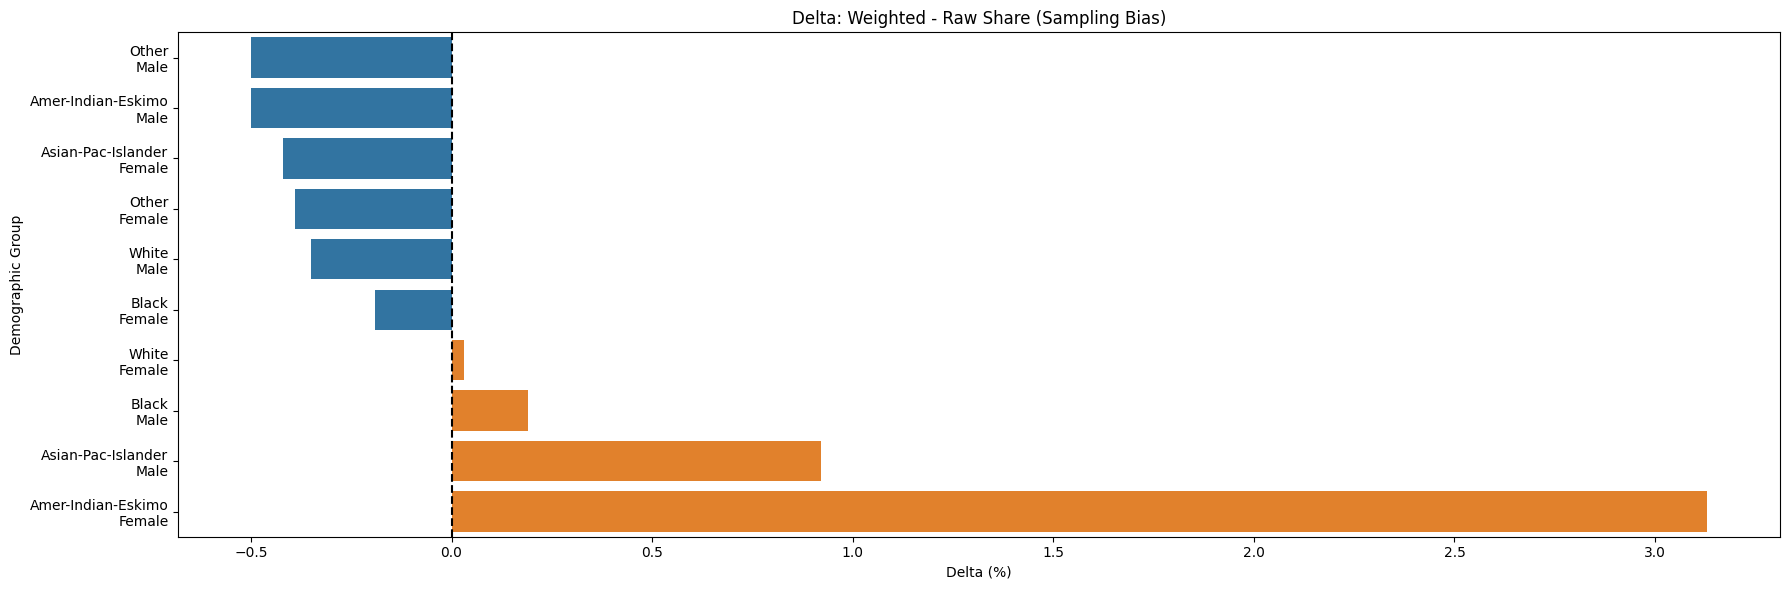

In [18]:
# --- Prepare Data for Grouped Bar ---
plot_data = group_share_df.melt(
    id_vars=['race','sex'], 
    value_vars=['Raw_Share (%)','Weighted_Share (%)'], 
    var_name='Metric', 
    value_name='Share'
)
plot_data['Group'] = plot_data['race'] + "\n" + plot_data['sex']

# --- Grouped Bar Chart ---
plt.figure(figsize=(18, 6))
ax = sns.barplot(data=plot_data, x='Group', y='Share', hue='Metric', palette='viridis')
[ax.bar_label(c, fmt='%.2f%%', padding=3) for c in ax.containers]
ax.set(title="Wealth Contribution: Raw vs Weighted", xlabel="Demographic Group", ylabel="Share (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Diverging Bar Chart for Delta ---
delta_df = group_share_df.copy()
delta_df['Group'] = delta_df['race'] + "\n" + delta_df['sex']

# Create a color column based on Delta sign
delta_df['Color'] = delta_df['Delta (%)'].apply(lambda x: 'green' if x > 0 else 'red')

plt.figure(figsize=(18,6))
sns.barplot(
    data=delta_df.sort_values('Delta (%)'),
    x='Delta (%)',
    y='Group',
    hue='Color',
    dodge=False,
    legend=False
)
plt.title("Delta: Weighted - Raw Share (Sampling Bias)")
plt.xlabel("Delta (%)")
plt.ylabel("Demographic Group")
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

### 3.2.5 Key Insights & Conclusion

Based on the weighted analysis of each Race × Sex group:

- **Most Under-Represented Group:**  
  *Amer-Indian-Eskimo Females* — Raw 10.08%, Weighted 13.21%, Delta +3.13%  
  → The survey underestimates their share of the wealthy population.

- **Least Biased Group:**  
  *White Females* — Raw 11.90%, Weighted 11.93%, Delta +0.03%  
  → The sample accurately reflects their population share.

**Conclusion:**  
- Overall, the dataset represents most groups well.  
- Significant under-representation occurs mainly in small minority groups and should be noted when analyzing these intersections.
